In [1]:
# ════════════════════════════════════════════════════════════════════════════════════
# PBT-Vision v5.5a: Probabilistic Module W — จาก EMA สู่ Generative Model
#
# CHANGE from v5.2: Module W upgraded from deterministic to PROBABILISTIC
#   v5.2 W:   h_predicted = h_prev + MLP(h_prev, V_acc)          [point estimate]
#   v5.5a W:  [μ, log_σ²] = h_prev + MLP(h_prev, V_acc)         [distribution]
#
# สิ่งที่เปลี่ยน:
#   1. Module W สร้าง μ + log_σ² (ไม่ใช่แค่ h_predicted)
#   2. Module E ใช้ μ เป็น prediction (เหมือนเดิมจากมุมของ E)
#   3. W Loss: NLL with log-variance trick (numerically stable)
#   4. V_epistemic ได้รับ uncertainty signal จาก σ² ด้วย
#
# สิ่งที่ไม่เปลี่ยน:
#   - Module A, Module E, Module V (probes), Module M (LSTM), Classifier
#   - Dataset (CIFAR-10 Enhanced เหมือน v3/v4.1/v5)
#   - DINOv2-Base backbone (frozen)
#   - Beta init [1,1,1] (equal init เหมือน v5.2)
#
# Base: DINOv2-Base | Dataset: CIFAR-10 Enhanced
# Predictive Boundary Theory — Ninthanawat N.
# Boundary Research Initiative, Bangkok, Thailand
# ════════════════════════════════════════════════════════════════════════════════════


# ════════════════════════════════════════════
# CELL 0: Install
# ════════════════════════════════════════════
# !pip install -q transformers accelerate datasets scikit-learn matplotlib seaborn torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoModel
from torchvision import transforms, datasets
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import random, time, copy, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB") # Corrected from .total_mem to .total_memory

# Constants
D_MODEL = 768
N_LAYERS = 12
SEQ_LEN = 8

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
# ════════════════════════════════════════════
# CELL 1: Architecture — v5.5a Probabilistic W
# ════════════════════════════════════════════

# ────────────────────────────────────────────
# MODULE A: Awareness Gate (IDENTICAL to v5.2)
# ────────────────────────────────────────────
class PBTModuleA(nn.Module):
    """Module A: R→Gating — Determines how much each layer contributes"""
    def __init__(self, n_layers=N_LAYERS, n_valence=3):
        super().__init__()
        self.r_weights = nn.Parameter(torch.tensor([1.0, 0.3, 0.5]))
        self.gate_net = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid()
        )
        self.n_layers = n_layers

    def compute_R(self, v_acc):
        R = (v_acc * self.r_weights).sum(dim=-1, keepdim=True)
        return R

    def compute_gates(self, R_total):
        B = R_total.shape[0]
        gates = []
        for l in range(self.n_layers):
            layer_pos = torch.full((B, 1), l / (self.n_layers - 1), device=R_total.device)
            gate_input = torch.cat([R_total, layer_pos], dim=-1)
            gate_l = self.gate_net(gate_input)
            gates.append(gate_l)
        return torch.cat(gates, dim=-1)

    def forward(self, v_acc):
        R_total = self.compute_R(v_acc)
        gates = self.compute_gates(R_total)
        return R_total, gates


# ════════════════════════════════════════════════════════════════════
# MODULE W v5.5a: PROBABILISTIC World Model ★ KEY CHANGE
#
# Theory: Module W creates p_world(S_predicted) as a DISTRIBUTION
#   v5.2:  h_predicted = h_prev + delta_pred          [point estimate]
#   v5.5a: mu, log_var = h_prev + delta_mu, log_var   [distribution!]
#
# W now predicts:
#   mu_l:      what SHOULD happen next (expected state)
#   log_var_l: how UNCERTAIN W is about this prediction
#
# log_var = log(sigma^2) trick (from Kendall & Gal, 2017):
#   - Network outputs log_var (can be any real number)
#   - sigma^2 = exp(log_var) (always positive, no division by zero)
#   - NLL loss: 0.5 * [exp(-log_var) * ||z - mu||^2 + log_var]
#
# V_epistemic will receive sigma^2 as UNCERTAINTY signal:
#   sigma^2 high → "ไม่แน่ใจ" → V_epistemic > 0 (อยากรู้)
#   sigma^2 low  → "แน่ใจ"    → V_epistemic < 0 (ไม่อยากรู้เพิ่ม)
# ════════════════════════════════════════════════════════════════════

class PBTModuleW_Probabilistic(nn.Module):
    """Module W v5.5a: Probabilistic Predictor — predicts mu + log_var"""
    def __init__(self, d_model=D_MODEL, n_layers=N_LAYERS, n_valence=3):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        # Shared feature extractor per layer (reduces params vs separate nets)
        self.shared_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model + n_valence, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
            ) for _ in range(n_layers)
        ])

        # Separate heads: mu and log_var
        self.mu_heads = nn.ModuleList([
            nn.Linear(256, d_model) for _ in range(n_layers)
        ])
        self.log_var_heads = nn.ModuleList([
            nn.Linear(256, 1) for _ in range(n_layers)  # scalar log_var per layer
        ])

        # Initialize log_var heads to output ~0 (sigma^2 = 1 = moderate uncertainty)
        for head in self.log_var_heads:
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, h_prev, v_acc):
        """
        h_prev: [B, N_LAYERS, D_MODEL]
        v_acc:  [B, 3]
        Returns:
          mu:      [B, N_LAYERS, D_MODEL] — predicted mean
          log_var: [B, N_LAYERS]           — log variance (uncertainty)
        """
        B = h_prev.shape[0]
        mu_list = []
        log_var_list = []

        for l in range(self.n_layers):
            h_l = h_prev[:, l, :]                              # [B, D_MODEL]
            pred_input = torch.cat([h_l, v_acc], dim=-1)       # [B, D_MODEL+3]

            features = self.shared_layers[l](pred_input)       # [B, 256]

            delta_mu = self.mu_heads[l](features)              # [B, D_MODEL]
            log_var_l = self.log_var_heads[l](features)        # [B, 1]

            mu_l = h_l + delta_mu                              # residual prediction
            mu_list.append(mu_l)
            log_var_list.append(log_var_l.squeeze(-1))         # [B]

        mu = torch.stack(mu_list, dim=1)                       # [B, N_LAYERS, D_MODEL]
        log_var = torch.stack(log_var_list, dim=1)             # [B, N_LAYERS]

        return mu, log_var

    def compute_nll_loss(self, h_actual, mu, log_var):
        """
        NLL Loss with log-variance trick (Kendall & Gal, 2017)
        L = 0.5 * [exp(-log_var) * ||h - mu||^2 + log_var]

        h_actual: [B, N_LAYERS, D_MODEL]
        mu:       [B, N_LAYERS, D_MODEL]
        log_var:  [B, N_LAYERS]
        """
        # ||h - mu||^2 per layer
        sq_error = (h_actual - mu).pow(2).mean(dim=-1)    # [B, N_LAYERS]

        # Clamp log_var for stability
        log_var_clamped = log_var.clamp(-10, 10)

        # NLL: 0.5 * [exp(-log_var) * error + log_var]
        nll = 0.5 * (torch.exp(-log_var_clamped) * sq_error + log_var_clamped)

        return nll.mean()  # scalar


# ────────────────────────────────────────────
# MODULE E: Prediction Error (IDENTICAL to v5.2)
# Now receives mu from Probabilistic W (same interface)
# ────────────────────────────────────────────
class PBTModuleE(nn.Module):
    """Module E: Precision-weighted Prediction Error"""
    def __init__(self, n_layers=N_LAYERS):
        super().__init__()
        self.log_precision = nn.Parameter(torch.zeros(n_layers))

    def get_precision(self):
        return torch.exp(self.log_precision)

    def forward(self, h_current, h_predicted):
        epsilon = h_current - h_predicted
        precision = self.get_precision().view(1, -1, 1)
        return epsilon * precision


# ────────────────────────────────────────────
# MODULE M v5: LSTM (IDENTICAL to v5.2 equal init)
# ────────────────────────────────────────────
class PBTModuleM_LSTM(nn.Module):
    """Module M v5: LSTM-style gates with differential beta per valence"""
    def __init__(self, n_valence=3, v_step_dim=3):
        super().__init__()
        self.n_valence = n_valence
        self.W_z = nn.Linear(v_step_dim, n_valence)
        self.W_i = nn.Linear(v_step_dim, n_valence)
        self.W_f = nn.Linear(v_step_dim, n_valence)
        self.beta = nn.Parameter(torch.tensor([1.0, 1.0, 1.0]))  # equal init

        nn.init.zeros_(self.W_z.weight); nn.init.zeros_(self.W_z.bias)
        nn.init.zeros_(self.W_i.weight); self.W_i.bias.data.fill_(-1.0)
        nn.init.zeros_(self.W_f.weight); self.W_f.bias.data.fill_(0.0)

    def get_beta(self):
        return self.beta

    def get_effective_forget_bias(self):
        return self.W_f.bias.data + self.beta.data

    def forward(self, v_step, v_acc_prev):
        z = torch.tanh(self.W_z(v_step))
        i = torch.sigmoid(self.W_i(v_step))
        f_raw = self.W_f(v_step) + self.beta
        f = torch.sigmoid(f_raw)
        v_acc_new = v_acc_prev * f + z * i
        return v_acc_new, {'f': f.detach(), 'i': i.detach(), 'z': z.detach()}


# ════════════════════════════════════════════════════════════════════
# FULL PBT-V v5.5a ADAPTER
#
# Changes from v5.2:
#   - Module W: PBTModuleW_Probabilistic (mu + log_var)
#   - Step 2: W returns mu, log_var (not just h_predicted)
#   - Step 3: E uses mu as prediction (same interface)
#   - Step 5b (NEW): V_epistemic receives uncertainty signal from sigma^2
#   - Loss: Classification + W_NLL (not just W_MSE)
# ════════════════════════════════════════════════════════════════════

class PBTVisionV55a(nn.Module):
    """
    v5.5a Loop:
    Step 1 (A): V_acc_prev -> R -> gates
    Step 2 (W): h_prev + V_acc -> mu, log_var  ★ PROBABILISTIC
    Step 3 (E): Pi * (h_current - mu) -> epsilon
    Step 4 (A*E): epsilon * gates -> epsilon_gated
    Step 5 (V): epsilon_gated -> (V_pain, V_pleasure, V_epistemic)
    Step 5b (NEW): V_epistemic += uncertainty_signal from sigma^2
    Step 6 (M): LSTM gated update
    Step 7: Classifier
    """
    def __init__(self, d_model=D_MODEL, n_layers=N_LAYERS):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        # Module A: IDENTICAL
        self.module_a = PBTModuleA(n_layers)

        # Module W: ★ PROBABILISTIC (KEY CHANGE)
        self.module_w = PBTModuleW_Probabilistic(d_model, n_layers)

        # Module E: IDENTICAL
        self.module_e = PBTModuleE(n_layers)

        # Module V: IDENTICAL probes
        self.valence_probes = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(0.1),
                nn.Linear(256, 3), nn.Sigmoid()
            ) for _ in range(n_layers)
        ])

        # ★ NEW: Uncertainty → V_epistemic modulation
        # Maps mean uncertainty (scalar) to epistemic valence adjustment
        self.uncertainty_to_epistemic = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(), nn.Linear(16, 1)
        )

        # Module M: IDENTICAL (LSTM equal init)
        self.module_m = PBTModuleM_LSTM(n_valence=3, v_step_dim=3)

        # Classifier: same size + 1 for mean_uncertainty
        in_features = d_model + (n_layers * 3) + 3 + 1 + 1  # +1 for uncertainty
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 2)
        )

        # Internal state
        self.prev_h = None
        self.v_acc = None

    def get_precision(self):
        return self.module_e.get_precision()

    def get_beta(self):
        return self.module_m.get_beta()

    def reset_state(self):
        self.prev_h = None
        self.v_acc = None

    def forward(self, h_current, return_details=False):
        B, L, D = h_current.shape

        if self.prev_h is None or self.prev_h.shape[0] != B:
            self.prev_h = h_current.detach()
            self.v_acc = torch.zeros(B, 3, device=h_current.device)

        # Step 1: Module A (IDENTICAL)
        R_total, gates = self.module_a(self.v_acc)

        # Step 2: Module W ★ PROBABILISTIC
        mu, log_var = self.module_w(self.prev_h, self.v_acc)
        # mu = predicted mean, log_var = log(sigma^2) per layer
        sigma_sq = torch.exp(log_var.clamp(-10, 10))          # [B, N_LAYERS]
        mean_uncertainty = sigma_sq.mean(dim=-1, keepdim=True) # [B, 1]

        # Step 3: Module E (uses mu as prediction — same interface!)
        epsilon = self.module_e(h_current, mu)

        # Step 4: A*E gating (IDENTICAL)
        gates_expanded = gates.unsqueeze(-1)
        epsilon_gated = epsilon * gates_expanded

        # Step 5: Module V (IDENTICAL probes)
        valences = []
        for l in range(self.n_layers):
            v_l = self.valence_probes[l](epsilon_gated[:, l, :])
            valences.append(v_l)
        v_feat = torch.cat(valences, dim=1)      # [B, N_LAYERS*3]
        v_layers = torch.stack(valences, dim=1)   # [B, N_LAYERS, 3]
        v_step = v_layers.mean(dim=1)             # [B, 3]

        # Step 5b ★ NEW: Uncertainty → V_epistemic modulation
        # sigma^2 high → "ไม่แน่ใจ" → boost V_epistemic (อยากรู้เพิ่ม)
        # sigma^2 low  → "แน่ใจแล้ว" → suppress V_epistemic (ไม่อยากรู้)
        epistemic_mod = self.uncertainty_to_epistemic(mean_uncertainty)  # [B, 1]
        v_step = v_step.clone()
        v_step[:, 2] = v_step[:, 2] + epistemic_mod.squeeze(-1)  # modulate epistemic

        # Step 6: Module M LSTM (IDENTICAL)
        self.v_acc, m_gates = self.module_m(v_step, self.v_acc)

        # Step 7: Classifier (+ uncertainty as feature)
        h_last = h_current[:, -1, :]
        combined = torch.cat([h_last, v_feat, self.v_acc, R_total, mean_uncertainty], dim=1)
        logits = self.classifier(combined)

        # Step 8: Update prev_h
        self.prev_h = h_current.detach()

        if return_details:
            eps_gated_norm = epsilon_gated.pow(2).mean(dim=-1).sqrt()
            details = {
                'R_total': R_total.detach(),
                'gates': gates.detach(),
                'epsilon_gated_norm': eps_gated_norm.detach(),
                'v_layers': v_layers.detach(),
                'v_step': v_step.detach(),
                'v_acc': self.v_acc.detach(),
                'h_predicted': mu.detach(),        # mu is the prediction
                'mu': mu.detach(),
                'log_var': log_var.detach(),
                'sigma_sq': sigma_sq.detach(),      # ★ NEW
                'mean_uncertainty': mean_uncertainty.detach(),  # ★ NEW
                'm_forget': m_gates['f'],
                'm_input': m_gates['i'],
            }
            return logits, details
        return logits, mu, log_var  # return log_var for W loss computation


# ════════════════════════════════════════════
# Instantiate
# ════════════════════════════════════════════
adapter = PBTVisionV55a().to(device)
total_params = sum(p.numel() for p in adapter.parameters())
w_params = sum(p.numel() for p in adapter.module_w.parameters())
print(f"\nPBT-V v5.5a Adapter:")
print(f"  Total params:    {total_params:,}")
print(f"  Module W params: {w_params:,} (Probabilistic)")
print(f"  Module M params: {sum(p.numel() for p in adapter.module_m.parameters()):,} (LSTM)")
print(f"  Beta init: {adapter.get_beta().data.tolist()} (equal)")



PBT-V v5.5a Adapter:
  Total params:    7,595,610
  Module W params: 4,743,180 (Probabilistic)
  Module M params: 39 (LSTM)
  Beta init: [1.0, 1.0, 1.0] (equal)


In [3]:
# ════════════════════════════════════════════
# CELL 2: Dataset (IDENTICAL to v3)
# ════════════════════════════════════════════
print("\n" + "=" * 90)
print("  Creating Enhanced CIFAR-10 Sequences (same as v3)")
print("=" * 90)

print("Downloading CIFAR-10...")
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True)

NORMAL_CLASSES = [1, 9]; ANOMALY_CLASSES = [0, 8]; TRICKY_CLASSES = [2, 4, 5]
NATURE_CLASSES = [2, 4, 5, 6, 7]  # bird, deer, dog, frog, horse
FROG_CLASS = 6
images_by_class = {i: [] for i in range(10)}
for img, label in cifar_train: images_by_class[label].append(img)
for img, label in cifar_test: images_by_class[label].append(img)

SEQ_LEN = 8

def create_sequence_v3(seq_type):
    frames, labels = [], []
    if seq_type == "normal_road":
        for _ in range(SEQ_LEN):
            cls = random.choice(NORMAL_CLASSES)
            frames.append(random.choice(images_by_class[cls])); labels.append(0)
    elif seq_type == "normal_nature":
        for _ in range(SEQ_LEN):
            cls = random.choice(NATURE_CLASSES)
            frames.append(random.choice(images_by_class[cls])); labels.append(0)
    elif seq_type == "sudden_anomaly":
        for i in range(SEQ_LEN):
            if i < SEQ_LEN // 2:
                cls = random.choice(NORMAL_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(0)
            else:
                cls = random.choice(ANOMALY_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(1)
    elif seq_type == "gradual_drift":
        transition = SEQ_LEN // 2
        for i in range(SEQ_LEN):
            if i < transition:
                cls = random.choice(NORMAL_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(0)
            elif i < transition + 2:
                cls = random.choice(NORMAL_CLASSES + ANOMALY_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(0)
            else:
                cls = random.choice(ANOMALY_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(1)
    elif seq_type == "drift_safe":
        for i in range(SEQ_LEN):
            if i < SEQ_LEN // 2:
                cls = random.choice(NORMAL_CLASSES)
            else:
                cls = random.choice(TRICKY_CLASSES)
            frames.append(random.choice(images_by_class[cls])); labels.append(0)
    elif seq_type == "context_road_frog":
        for i in range(SEQ_LEN):
            if i < SEQ_LEN // 2:
                cls = random.choice(NORMAL_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(0)
            else:
                frames.append(random.choice(images_by_class[FROG_CLASS])); labels.append(1)
    elif seq_type == "context_nature_frog":
        for i in range(SEQ_LEN):
            if i < SEQ_LEN // 2:
                cls = random.choice(NATURE_CLASSES)
                frames.append(random.choice(images_by_class[cls])); labels.append(0)
            else:
                frames.append(random.choice(images_by_class[FROG_CLASS])); labels.append(0)
    return frames, labels

configs = [("normal_road",300),("normal_nature",200),("sudden_anomaly",200),
           ("gradual_drift",300),("drift_safe",150),("context_road_frog",200),("context_nature_frog",200)]
all_sequences = []
for stype, count in configs:
    for _ in range(count):
        frames, labels = create_sequence_v3(stype)
        all_sequences.append({"frames": frames, "labels": labels, "type": stype})
random.shuffle(all_sequences)

n_total = len(all_sequences)
n_train = int(n_total * 0.70); n_val = int(n_total * 0.15)
train_seqs = all_sequences[:n_train]
val_seqs = all_sequences[n_train:n_train+n_val]
test_seqs = all_sequences[n_train+n_val:]
print(f"Total: {n_total} seq × {SEQ_LEN} frames = {n_total*SEQ_LEN} frames")
print(f"Train: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}")


  Creating Enhanced CIFAR-10 Sequences (same as v3)


100%|██████████| 170M/170M [00:07<00:00, 21.4MB/s]


Total: 1550 seq × 8 frames = 12400 frames
Train: 1085 | Val: 232 | Test: 233


In [5]:
# ════════════════════════════════════════════
# CELL 3: Pre-compute Hidden States (same as v3)
# ════════════════════════════════════════════

# Import AutoProcessor and load DINOv2 model and processor
from transformers import AutoProcessor, AutoModel

# Ensure the DINOv2 model and processor are loaded (they should be here if not in CELL 0)
# This assumes 'dinov2_base' is the intended model name.
processor = AutoProcessor.from_pretrained("facebook/dinov2-base")
base_model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)

print("\n" + "=" * 90)
print("  Pre-computing Hidden States")
print("=" * 90)

def extract_sequence_features(sequences, desc=""):
    all_h, all_labels, all_types = [], [], []
    t0 = time.time()
    for i, seq in enumerate(sequences):
        seq_h = []
        for frame_img in seq["frames"]:
            inputs = processor(images=frame_img, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = base_model(**inputs, output_hidden_states=True)
            layer_h = torch.stack([outputs.hidden_states[l+1][:, 0, :].squeeze(0).cpu() for l in range(N_LAYERS)], dim=0)
            seq_h.append(layer_h)
        all_h.append(torch.stack(seq_h, dim=0))
        all_labels.append(torch.tensor(seq["labels"]))
        all_types.append(seq["type"])
        if (i+1) % 200 == 0: print(f"    {desc} {i+1}/{len(sequences)} ({time.time()-t0:.0f}s)")
    print(f"  {desc} done: {len(sequences)} seq in {time.time()-t0:.0f}s")
    return all_h, all_labels, all_types

print("\n  TRAIN..."); train_h, train_labels, train_types = extract_sequence_features(train_seqs, "Train")
print("\n  VAL..."); val_h, val_labels, val_types = extract_sequence_features(val_seqs, "Val")
print("\n  TEST..."); test_h, test_labels, test_types = extract_sequence_features(test_seqs, "Test")



preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]


  Pre-computing Hidden States

  TRAIN...
    Train 200/1085 (17s)
    Train 400/1085 (33s)
    Train 600/1085 (49s)
    Train 800/1085 (64s)
    Train 1000/1085 (80s)
  Train done: 1085 seq in 87s

  VAL...
    Val 200/232 (16s)
  Val done: 232 seq in 18s

  TEST...
    Test 200/233 (16s)
  Test done: 233 seq in 18s



  Training PBT-V v5.5a (A-E-V-M_LSTM-W_Probabilistic Loop)
  KEY: Module W now predicts mu + log_var (Probabilistic)
  Epoch  0 | Loss 3.739 | W_NLL -2.500 | Train 90.2% | Val 91.6% | β [0.85,0.86,0.84] | σ² 0.2672 | Π_max 2.16 ★ BEST
  Epoch  4 | Loss 2.133 | W_NLL -3.240 | Train 92.8% | Val 92.6% | β [1.70,0.93,1.38] | σ² 0.5564 | Π_max 3.39 ★ BEST
  Epoch  5 | Loss 0.953 | W_NLL -3.291 | Train 97.2% | Val 96.8% | β [1.90,0.92,1.50] | σ² 0.2981 | Π_max 3.72 ★ BEST
  Epoch  8 | Loss 0.639 | W_NLL -3.384 | Train 98.4% | Val 96.8% | β [2.25,0.61,1.44] | σ² 0.2449 | Π_max 4.94 ★ BEST
  Epoch 10 | Loss 0.475 | W_NLL -3.411 | Train 98.8% | Val 96.8% | β [2.46,0.29,1.30] | σ² 0.2328 | Π_max 4.84
  Epoch 12 | Loss 0.594 | W_NLL -3.428 | Train 99.0% | Val 97.0% | β [2.61,0.10,1.22] | σ² 0.2270 | Π_max 5.56 ★ BEST
  Epoch 15 | Loss 0.248 | W_NLL -3.457 | Train 99.5% | Val 96.3% | β [2.61,-0.03,1.19] | σ² 0.2212 | Π_max 4.33
  Epoch 20 | Loss 0.258 | W_NLL -3.497 | Train 99.6% | Val 96.4% | β 

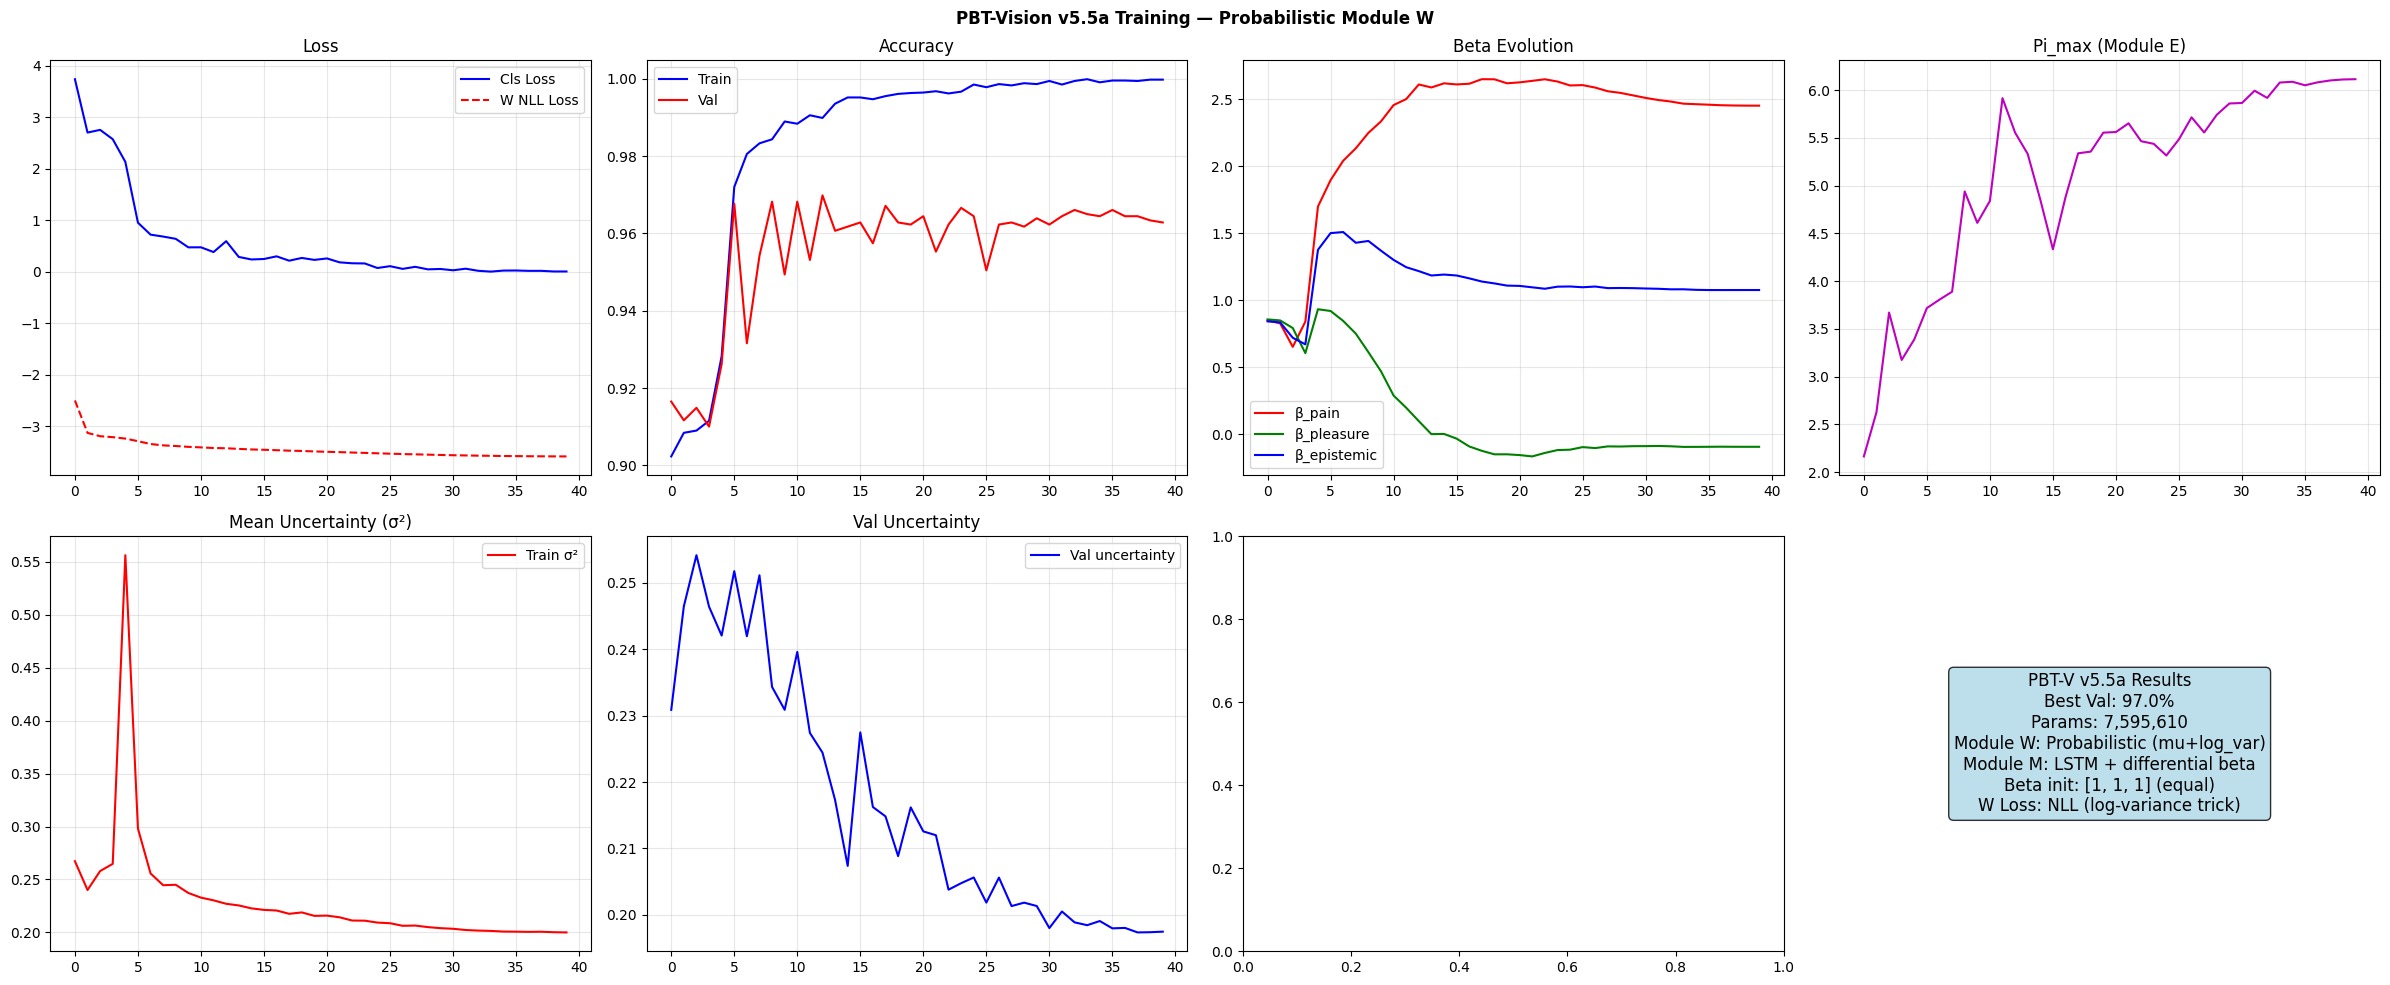

Saved: pbt_vision_v55a.pth


In [6]:
# ════════════════════════════════════════════
# CELL 4: Training with NLL Loss for Probabilistic W
# ════════════════════════════════════════════
# KEY CHANGE from v5.2:
#   v5.2 W loss:  MSE = ||h_actual - h_predicted||^2
#   v5.5a W loss: NLL = 0.5 * [exp(-log_var) * ||h - mu||^2 + log_var]
#
#   NLL ทำให้ W เรียนรู้ "ความไม่แน่นอน" ของตัวเอง:
#     - ถ้า W ทำนายผิด → ลด loss ได้โดยเพิ่ม log_var (ยอมรับว่าไม่แน่ใจ)
#     - ถ้า W ทำนายถูก → ลด loss ได้โดยลด log_var (มั่นใจ)
#     - ไม่มี division by zero (ใช้ exp(-log_var) แทน 1/sigma^2)
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Training PBT-V v5.5a (A-E-V-M_LSTM-W_Probabilistic Loop)")
print("  KEY: Module W now predicts mu + log_var (Probabilistic)")
print("=" * 90)

optimizer = AdamW([
    {'params': adapter.classifier.parameters(), 'lr': 1e-3},
    {'params': adapter.valence_probes.parameters(), 'lr': 1e-3},
    {'params': adapter.module_e.parameters(), 'lr': 5e-3, 'weight_decay': 0},
    {'params': adapter.module_m.parameters(), 'lr': 3e-3, 'weight_decay': 0},
    {'params': adapter.module_a.parameters(), 'lr': 2e-3},
    {'params': adapter.module_w.parameters(), 'lr': 1e-3},  # W learns both mu and log_var
    {'params': adapter.uncertainty_to_epistemic.parameters(), 'lr': 1e-3},  # NEW
])
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

# W NLL loss weight (increased from 0.1 because NLL is more informative)
w_nll_weight = 0.2

EPOCHS = 40; best_val_acc = 0; best_state = None
history = {
    'loss': [], 'w_nll_loss': [], 'train_acc': [], 'val_acc': [],
    'beta_p': [], 'beta_pl': [], 'beta_e': [],
    'pi_max': [], 'R_mean': [], 'gate_mean': [],
    'mean_uncertainty': [], 'log_var_mean': [],  # NEW: track uncertainty
}

adapter.train(); t0 = time.time()

for epoch in range(EPOCHS):
    epoch_loss = 0; epoch_w_nll = 0; all_preds = []; all_true = []
    epoch_uncertainty = []
    indices = list(range(len(train_h))); random.shuffle(indices)

    for idx in indices:
        seq_h = train_h[idx].to(device)
        seq_labels = train_labels[idx].to(device)
        adapter.reset_state(); optimizer.zero_grad()

        seq_loss = 0; seq_w_nll = 0
        for t in range(SEQ_LEN):
            h_t = seq_h[t].unsqueeze(0)
            label_t = seq_labels[t].unsqueeze(0)

            # Forward: returns logits, mu, log_var
            logits, mu, log_var = adapter(h_t, return_details=False)
            cls_loss = criterion(logits, label_t)

            # ★ W NLL Loss (log-variance trick)
            if adapter.prev_h is not None and t > 0:
                w_nll = adapter.module_w.compute_nll_loss(h_t, mu, log_var)
                seq_w_nll = seq_w_nll + w_nll * w_nll_weight

                # Track uncertainty
                with torch.no_grad():
                    sigma_sq = torch.exp(log_var.clamp(-10, 10))
                    epoch_uncertainty.append(sigma_sq.mean().item())

            seq_loss = seq_loss + cls_loss
            all_preds.append(logits.argmax(-1).item())
            all_true.append(label_t.item())

        total_loss = seq_loss + seq_w_nll
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
        optimizer.step()
        epoch_loss += seq_loss.item()
        epoch_w_nll += seq_w_nll.item() if not isinstance(seq_w_nll, (int, float)) else seq_w_nll

    scheduler.step()

    # Validation
    adapter.eval()
    val_preds, val_true = [], []
    val_uncertainty = []
    with torch.no_grad():
        for idx in range(len(val_h)):
            adapter.reset_state()
            for t in range(SEQ_LEN):
                h_t = val_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                val_preds.append(logits.argmax(-1).item())
                val_true.append(val_labels[idx][t].item())
                val_uncertainty.append(details['mean_uncertainty'].item())
    adapter.train()

    train_acc = accuracy_score(all_true, all_preds)
    val_acc = accuracy_score(val_true, val_preds)
    betas = adapter.get_beta().detach().cpu().numpy()
    precs = adapter.get_precision().detach().cpu().numpy()

    # Save history
    history['loss'].append(epoch_loss / len(train_h))
    history['w_nll_loss'].append(epoch_w_nll / len(train_h))
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['beta_p'].append(betas[0])
    history['beta_pl'].append(betas[1])
    history['beta_e'].append(betas[2])
    history['pi_max'].append(precs.max())
    history['R_mean'].append(0)
    history['gate_mean'].append(0)
    history['mean_uncertainty'].append(np.mean(epoch_uncertainty) if epoch_uncertainty else 0)
    history['log_var_mean'].append(np.mean(val_uncertainty) if val_uncertainty else 0)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(adapter.state_dict())
        marker = " ★ BEST"
    else:
        marker = ""

    if epoch % 5 == 0 or marker:
        mean_unc = np.mean(epoch_uncertainty) if epoch_uncertainty else 0
        print(f"  Epoch {epoch:2d} | Loss {epoch_loss/len(train_h):.3f} | "
              f"W_NLL {epoch_w_nll/len(train_h):.3f} | "
              f"Train {train_acc:.1%} | Val {val_acc:.1%} | "
              f"β [{betas[0]:.2f},{betas[1]:.2f},{betas[2]:.2f}] | "
              f"σ² {mean_unc:.4f} | "
              f"Π_max {precs.max():.2f}{marker}")

adapter.load_state_dict(best_state); adapter.eval()
print(f"\nBest val: {best_val_acc:.1%}")
print(f"Training time: {time.time()-t0:.0f}s")

# ═══════════════════════════════════════════
# Training Visualization (7 panels — added uncertainty)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
epochs_range = range(len(history['loss']))

axes[0,0].plot(epochs_range, history['loss'], 'b-', label='Cls Loss')
axes[0,0].plot(epochs_range, history['w_nll_loss'], 'r--', label='W NLL Loss')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[0,1].plot(epochs_range, history['val_acc'], 'r-', label='Val')
axes[0,1].set_title('Accuracy'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(epochs_range, history['beta_p'], 'r-', label='β_pain')
axes[0,2].plot(epochs_range, history['beta_pl'], 'g-', label='β_pleasure')
axes[0,2].plot(epochs_range, history['beta_e'], 'b-', label='β_epistemic')
axes[0,2].set_title('Beta Evolution'); axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

axes[0,3].plot(epochs_range, history['pi_max'], 'm-')
axes[0,3].set_title('Pi_max (Module E)'); axes[0,3].grid(True, alpha=0.3)

# ★ NEW: Uncertainty evolution
axes[1,0].plot(epochs_range, history['mean_uncertainty'], 'r-', label='Train σ²')
axes[1,0].set_title('Mean Uncertainty (σ²)'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs_range, history['log_var_mean'], 'b-', label='Val uncertainty')
axes[1,1].set_title('Val Uncertainty'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# W NLL vs Classification loss ratio
if history['w_nll_loss'][-1] > 0:
    ratio = [c/(w+1e-10) for c, w in zip(history['loss'], history['w_nll_loss'])]
    axes[1,2].plot(epochs_range, ratio, 'g-')
    axes[1,2].set_title('Cls/W_NLL Ratio'); axes[1,2].grid(True, alpha=0.3)

axes[1,3].axis('off')
axes[1,3].text(0.5, 0.5,
    f'PBT-V v5.5a Results\n'
    f'Best Val: {best_val_acc:.1%}\n'
    f'Params: {total_params:,}\n'
    f'Module W: Probabilistic (mu+log_var)\n'
    f'Module M: LSTM + differential beta\n'
    f'Beta init: [1, 1, 1] (equal)\n'
    f'W Loss: NLL (log-variance trick)',
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('PBT-Vision v5.5a Training — Probabilistic Module W', fontweight='bold')
plt.tight_layout()
plt.savefig('pbtv55a_training.png', dpi=150)
plt.show()

# Save checkpoint
torch.save({
    "state_dict": best_state,
    "config": {
        "version": "v5.5a_probabilistic_W",
        "d_model": D_MODEL, "n_layers": N_LAYERS,
        "best_val_acc": best_val_acc,
        "w_loss_type": "NLL_log_variance_trick",
        "beta_init": [1.0, 1.0, 1.0],
        "total_params": total_params,
        "w_params": w_params,
    }
}, "pbt_vision_v55a.pth")
print("Saved: pbt_vision_v55a.pth")


In [8]:
# ════════════════════════════════════════════
# CELL 5: Comprehensive Test + Ablation (Fixed for v5.5a)
# ════════════════════════════════════════════
print("\n" + "=" * 90)
print("  Comprehensive Test + Ablation — PBT-V v5.5a")
print("=" * 90)

# Full test
adapter.eval()
test_preds, test_true, test_type_list = [], [], []
with torch.no_grad():
    for idx in range(len(test_h)):
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            logits, details = adapter(h_t, return_details=True)
            test_preds.append(logits.argmax(-1).item())
            test_true.append(test_labels[idx][t].item())
            test_type_list.append(test_types[idx])

overall_acc = accuracy_score(test_true, test_preds)
print(f"\nOverall: {overall_acc:.1%}")
print(f"\n{classification_report(test_true, test_preds, target_names=['SAFE','ANOMALY'], digits=4)}")

print("\nBy Type:")
for stype in sorted(set(test_type_list)):
    idx = [i for i,t in enumerate(test_type_list) if t == stype]
    acc = accuracy_score([test_true[i] for i in idx], [test_preds[i] for i in idx])
    print(f"  {stype:25s}: {acc:.1%} ({len(idx)} frames)")

# ═══ ABLATION ═══
def run_ablation(ablate_list, name):
    # Use the correct class name for v5.5a
    abl = PBTVisionV55a().to(device)
    abl.load_state_dict(best_state); abl.eval()

    with torch.no_grad():
        if 'E' in ablate_list: abl.module_e.log_precision.fill_(0.0)
        if 'W' in ablate_list:
            # Disable W predictors
            for head in abl.module_w.mu_heads: head.weight.data.fill_(0.0); head.bias.data.fill_(0.0)

        preds, true = [], []
        for idx in range(len(test_h)):
            abl.reset_state()
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                if 'A' in ablate_list:
                    abl.module_a.r_weights.data.fill_(0.0)
                if 'M' in ablate_list:
                    abl.v_acc = torch.zeros(1, 3, device=device)

                # Handle probabilistic output format
                logits, mu, log_var = abl(h_t, return_details=False)
                preds.append(logits.argmax(-1).item())
                true.append(test_labels[idx][t].item())

    acc = accuracy_score(true, preds)
    return acc

print("\nRunning ablations (Overall Accuracy)...")
acc_full = overall_acc
acc_noA = run_ablation(['A'], "No A")
acc_noW = run_ablation(['W'], "No W")
acc_noE = run_ablation(['E'], "No E")
acc_noM = run_ablation(['M'], "No M")

print(f"\n{'Configuration':<30s} {'Overall':>8s}")
print("─" * 40)
print(f"  {'Full (A+E+V+M+W)':<28s} {acc_full:>7.1%}")
print(f"  {'No A (no gating)':<28s} {acc_noA:>7.1%}")
print(f"  {'No W (naive predict)':<28s} {acc_noW:>7.1%}")
print(f"  {'No E (uniform Pi)':<28s} {acc_noE:>7.1%}")
print(f"  {'No M (no memory)':<28s} {acc_noM:>7.1%}")



  Comprehensive Test + Ablation — PBT-V v5.5a

Overall: 97.5%

              precision    recall  f1-score   support

        SAFE     0.9934    0.9759    0.9846      1536
     ANOMALY     0.8958    0.9695    0.9312       328

    accuracy                         0.9748      1864
   macro avg     0.9446    0.9727    0.9579      1864
weighted avg     0.9762    0.9748    0.9752      1864


By Type:
  context_nature_frog      : 99.6% (232 frames)
  context_road_frog        : 99.2% (256 frames)
  drift_safe               : 100.0% (264 frames)
  gradual_drift            : 87.8% (304 frames)
  normal_nature            : 99.7% (288 frames)
  normal_road              : 100.0% (272 frames)
  sudden_anomaly           : 97.6% (248 frames)

Running ablations (Overall Accuracy)...

Configuration                   Overall
────────────────────────────────────────
  Full (A+E+V+M+W)               97.5%
  No A (no gating)               90.8%
  No W (naive predict)           97.1%
  No E (uniform Pi)  

In [9]:
# ════════════════════════════════════════════
# CELL 6: Context Test — Same Frog, Different Meaning
# ════════════════════════════════════════════
print("\n" + "=" * 90)
print("  Context Test: Same Frog, Different Meaning (v5 LSTM)")
print("=" * 90)

# Find road+frog and nature+frog sequences in test
road_frog_idx = next((i for i,t in enumerate(test_types) if t=="context_road_frog"), None)
nature_frog_idx = next((i for i,t in enumerate(test_types) if t=="context_nature_frog"), None)

if road_frog_idx is not None and nature_frog_idx is not None:
    for label, idx in [("Road+Frog (should be UNSAFE)", road_frog_idx), ("Nature+Frog (should be SAFE)", nature_frog_idx)]:
        adapter.reset_state()
        print(f"\n  {label}:")
        with torch.no_grad():
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                prob = F.softmax(logits, dim=-1)[0, 1].item()
                R = details['R_total'][0, 0].item()
                gate_mean = details['gates'][0].mean().item()
                print(f"    Frame {t}: UNSAFE={prob:.3f} R={R:.3f} gate_mean={gate_mean:.3f} "
                      f"V_acc=[{details['v_acc'][0,0]:.2f}, {details['v_acc'][0,1]:.2f}, {details['v_acc'][0,2]:.2f}]")




  Context Test: Same Frog, Different Meaning (v5 LSTM)

  Road+Frog (should be UNSAFE):
    Frame 0: UNSAFE=0.000 R=0.000 gate_mean=0.481 V_acc=[0.26, 0.01, 0.00]
    Frame 1: UNSAFE=0.000 R=0.928 gate_mean=0.795 V_acc=[0.52, 0.02, 0.00]
    Frame 2: UNSAFE=0.000 R=1.815 gate_mean=0.921 V_acc=[0.78, 0.02, 0.00]
    Frame 3: UNSAFE=0.000 R=2.734 gate_mean=0.975 V_acc=[1.05, 0.02, 0.03]
    Frame 4: UNSAFE=1.000 R=3.717 gate_mean=0.993 V_acc=[1.28, 0.01, -0.01]
    Frame 5: UNSAFE=1.000 R=4.398 gate_mean=0.997 V_acc=[1.35, -0.02, -0.08]
    Frame 6: UNSAFE=1.000 R=4.466 gate_mean=0.997 V_acc=[1.32, -0.02, -0.20]
    Frame 7: UNSAFE=1.000 R=4.082 gate_mean=0.996 V_acc=[1.56, 0.00, -0.16]

  Nature+Frog (should be SAFE):
    Frame 0: UNSAFE=0.000 R=0.000 gate_mean=0.481 V_acc=[0.01, -0.03, -0.10]
    Frame 1: UNSAFE=0.000 R=-0.236 gate_mean=0.388 V_acc=[0.15, -0.01, -0.13]
    Frame 2: UNSAFE=0.000 R=0.223 gate_mean=0.572 V_acc=[-0.31, -0.06, -0.34]
    Frame 3: UNSAFE=0.000 R=-1.940 gate


  Module Analysis — v5.5a Probabilistic W

  Module E Precision Pi_l:
    Layer  0 (Perception): Pi = 5.5553
    Layer  1 (Perception): Pi = 0.9735
    Layer  2 (Perception): Pi = 1.2550
    Layer  3 (Perception): Pi = 4.1460
    Layer  4 (Evaluation): Pi = 3.2535
    Layer  5 (Evaluation): Pi = 1.7233
    Layer  6 (Evaluation): Pi = 2.9774
    Layer  7 (Evaluation): Pi = 2.6702
    Layer  8 (Decision  ): Pi = 2.7843
    Layer  9 (Decision  ): Pi = 0.7440
    Layer 10 (Decision  ): Pi = 0.6748
    Layer 11 (Decision  ): Pi = 0.8181

  Module M v5 — LSTM Gates:
    Beta (differential forget bias):
      beta_pain     = 2.6096
      beta_pleasure = 0.0993
      beta_epistemic= 1.2178
    Effective forget bias (b_f + beta):
      pain     = 4.2193 → sigmoid = 0.9855
      pleasure = -0.8015 → sigmoid = 0.3097
      epistemic= 1.4356 → sigmoid = 0.8078

  ★ Module W — Uncertainty Analysis (sigma^2 per layer)

    Layer                   σ²_safe    σ²_unsafe        Δσ²   MSE_safe   MSE_uns

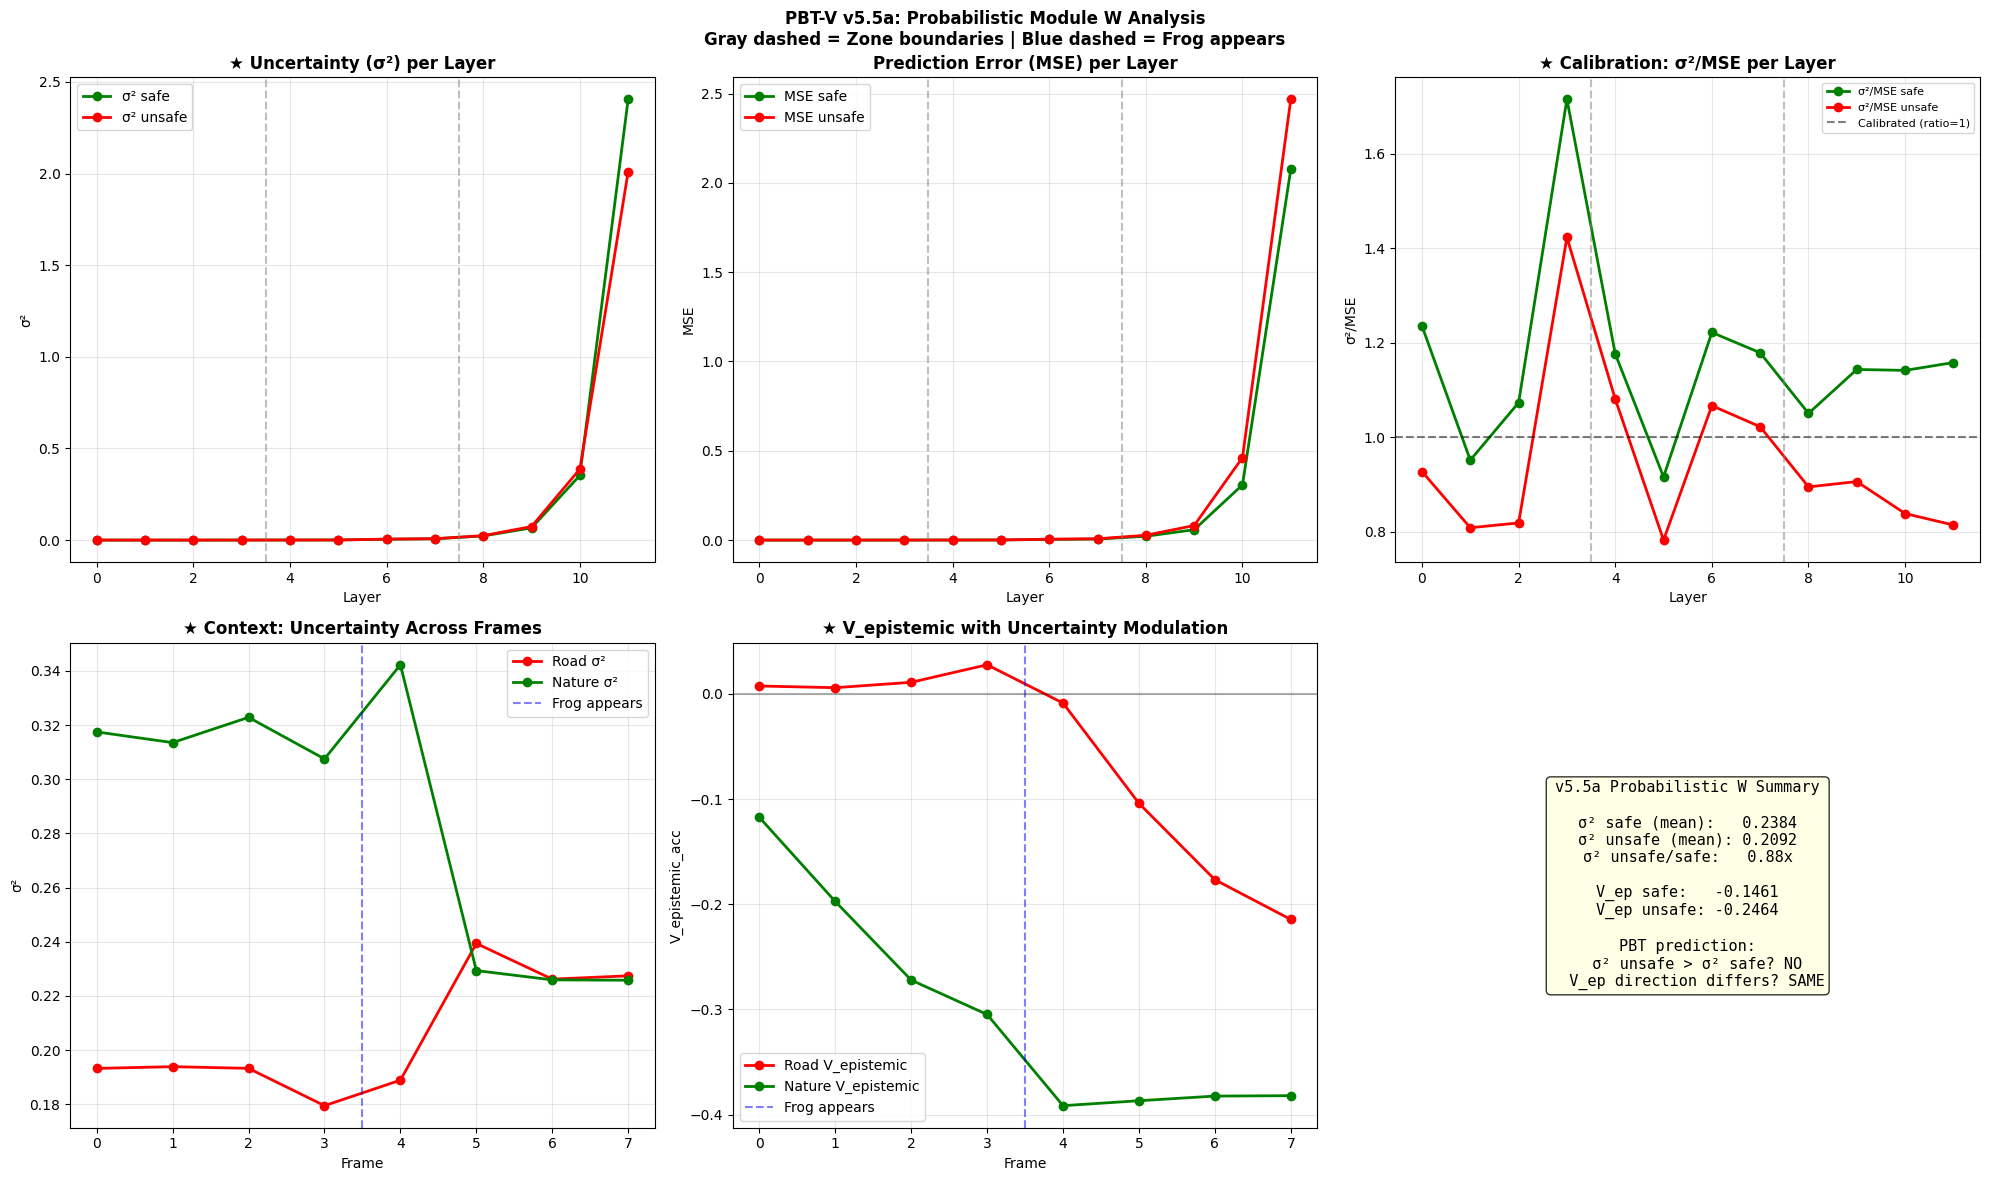


  v5.5a Analysis Complete!


In [10]:
# ════════════════════════════════════════════
# CELL 7: Module Analysis — v5.5a Probabilistic W
# ════════════════════════════════════════════
# NEW analyses compared to v5.2:
#   - Uncertainty (sigma^2) per layer
#   - Uncertainty: safe vs unsafe
#   - W prediction quality: NLL vs MSE comparison
#   - V_epistemic modulation from uncertainty
# ════════════════════════════════════════════

print("\n" + "=" * 90)
print("  Module Analysis — v5.5a Probabilistic W")
print("=" * 90)

precs = adapter.get_precision().detach().cpu().numpy()
betas = adapter.get_beta().detach().cpu().numpy()
eff_bias = adapter.module_m.get_effective_forget_bias().cpu().numpy()

print(f"\n  Module E Precision Pi_l:")
for l in range(N_LAYERS):
    zone = "Perception" if l < 4 else "Evaluation" if l < 8 else "Decision"
    print(f"    Layer {l:2d} ({zone:10s}): Pi = {precs[l]:.4f}")

print(f"\n  Module M v5 — LSTM Gates:")
print(f"    Beta (differential forget bias):")
print(f"      beta_pain     = {betas[0]:.4f}")
print(f"      beta_pleasure = {betas[1]:.4f}")
print(f"      beta_epistemic= {betas[2]:.4f}")
print(f"    Effective forget bias (b_f + beta):")
print(f"      pain     = {eff_bias[0]:.4f} → sigmoid = {1/(1+np.exp(-eff_bias[0])):.4f}")
print(f"      pleasure = {eff_bias[1]:.4f} → sigmoid = {1/(1+np.exp(-eff_bias[1])):.4f}")
print(f"      epistemic= {eff_bias[2]:.4f} → sigmoid = {1/(1+np.exp(-eff_bias[2])):.4f}")

# ════════════════════════════════════════════
# ★ NEW: Uncertainty Analysis (sigma^2 per layer)
# ════════════════════════════════════════════
print(f"\n  ★ Module W — Uncertainty Analysis (sigma^2 per layer)")

layer_sigma_safe = [[] for _ in range(N_LAYERS)]
layer_sigma_unsafe = [[] for _ in range(N_LAYERS)]
layer_mse_safe = [[] for _ in range(N_LAYERS)]
layer_mse_unsafe = [[] for _ in range(N_LAYERS)]
epistemic_mod_safe = []
epistemic_mod_unsafe = []

with torch.no_grad():
    for idx in range(len(test_h)):
        adapter.reset_state()
        for t in range(SEQ_LEN):
            h_t = test_h[idx][t].unsqueeze(0).to(device)
            logits, details = adapter(h_t, return_details=True)

            sigma_sq = details['sigma_sq'][0].cpu().numpy()     # [N_LAYERS]
            mu = details['mu'][0].cpu().numpy()                  # [N_LAYERS, D_MODEL]
            h_actual = h_t[0].cpu().numpy()                      # [N_LAYERS, D_MODEL]
            mean_unc = details['mean_uncertainty'][0, 0].item()
            label = test_labels[idx][t].item()

            for l in range(N_LAYERS):
                mse_l = ((h_actual[l] - mu[l]) ** 2).mean()
                if label == 0:
                    layer_sigma_safe[l].append(sigma_sq[l])
                    layer_mse_safe[l].append(mse_l)
                else:
                    layer_sigma_unsafe[l].append(sigma_sq[l])
                    layer_mse_unsafe[l].append(mse_l)

            if label == 0:
                epistemic_mod_safe.append(details['v_step'][0, 2].item())
            else:
                epistemic_mod_unsafe.append(details['v_step'][0, 2].item())

print(f"\n    {'Layer':<20s} {'σ²_safe':>10s} {'σ²_unsafe':>12s} {'Δσ²':>10s} "
      f"{'MSE_safe':>10s} {'MSE_unsafe':>12s} {'Δ_MSE':>10s}")
print(f"    {'─'*85}")
for l in range(N_LAYERS):
    s_safe = np.mean(layer_sigma_safe[l]) if layer_sigma_safe[l] else 0
    s_unsafe = np.mean(layer_sigma_unsafe[l]) if layer_sigma_unsafe[l] else 0
    m_safe = np.mean(layer_mse_safe[l]) if layer_mse_safe[l] else 0
    m_unsafe = np.mean(layer_mse_unsafe[l]) if layer_mse_unsafe[l] else 0
    zone = "Perception" if l < 4 else "Evaluation" if l < 8 else "Decision"
    print(f"    Layer {l:2d} ({zone:10s}) {s_safe:>10.4f} {s_unsafe:>12.4f} {s_unsafe-s_safe:>+10.4f} "
          f"{m_safe:>10.4f} {m_unsafe:>12.4f} {m_unsafe-m_safe:>+10.4f}")

print(f"\n  ★ V_epistemic with uncertainty modulation:")
print(f"    V_epistemic (safe):   {np.mean(epistemic_mod_safe):.4f} ± {np.std(epistemic_mod_safe):.4f}")
print(f"    V_epistemic (unsafe): {np.mean(epistemic_mod_unsafe):.4f} ± {np.std(epistemic_mod_unsafe):.4f}")

# ════════════════════════════════════════════
# ★ NEW: Context Test with Uncertainty
# ════════════════════════════════════════════
print(f"\n  ★ Context Test — Uncertainty Divergence")

road_frog_idx = [i for i, t in enumerate(test_types) if t == "context_road_frog"]
nature_frog_idx = [i for i, t in enumerate(test_types) if t == "context_nature_frog"]

def analyze_uncertainty_sequence(indices, label):
    frame_data = {t: {'sigma_sq': [], 'prob': [], 'v_ep': []} for t in range(SEQ_LEN)}
    with torch.no_grad():
        for idx in indices:
            adapter.reset_state()
            for t in range(SEQ_LEN):
                h_t = test_h[idx][t].unsqueeze(0).to(device)
                logits, details = adapter(h_t, return_details=True)
                prob = F.softmax(logits, dim=-1)[0, 1].item()
                sigma_sq_mean = details['sigma_sq'][0].mean().item()
                v_ep = details['v_acc'][0, 2].item()
                frame_data[t]['sigma_sq'].append(sigma_sq_mean)
                frame_data[t]['prob'].append(prob)
                frame_data[t]['v_ep'].append(v_ep)

    print(f"\n    {label}:")
    print(f"    {'Frame':>5s} {'UNSAFE':>8s} {'σ²_mean':>10s} {'V_epistemic':>12s}")
    print(f"    {'─'*40}")
    for t in range(SEQ_LEN):
        p = np.mean(frame_data[t]['prob'])
        s = np.mean(frame_data[t]['sigma_sq'])
        v = np.mean(frame_data[t]['v_ep'])
        print(f"    {t:>5d} {p:>8.4f} {s:>10.4f} {v:>+12.4f}")
    return frame_data

road_data = analyze_uncertainty_sequence(road_frog_idx, "Road+Frog (UNSAFE)")
nature_data = analyze_uncertainty_sequence(nature_frog_idx, "Nature+Frog (SAFE)")

# ════════════════════════════════════════════
# Visualization: 6 panels
# ════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
layers = list(range(N_LAYERS))

# 1: sigma^2 per layer (safe vs unsafe)
ax = axes[0, 0]
s_safe = [np.mean(layer_sigma_safe[l]) for l in range(N_LAYERS)]
s_unsafe = [np.mean(layer_sigma_unsafe[l]) for l in range(N_LAYERS)]
ax.plot(layers, s_safe, 'g-o', lw=2, label='σ² safe')
ax.plot(layers, s_unsafe, 'r-o', lw=2, label='σ² unsafe')
ax.axvline(x=3.5, color='gray', ls='--', alpha=0.5)
ax.axvline(x=7.5, color='gray', ls='--', alpha=0.5)
ax.set_title('★ Uncertainty (σ²) per Layer', fontweight='bold')
ax.set_xlabel('Layer'); ax.set_ylabel('σ²'); ax.legend(); ax.grid(True, alpha=0.3)

# 2: MSE per layer (safe vs unsafe)
ax = axes[0, 1]
m_safe = [np.mean(layer_mse_safe[l]) for l in range(N_LAYERS)]
m_unsafe = [np.mean(layer_mse_unsafe[l]) for l in range(N_LAYERS)]
ax.plot(layers, m_safe, 'g-o', lw=2, label='MSE safe')
ax.plot(layers, m_unsafe, 'r-o', lw=2, label='MSE unsafe')
ax.axvline(x=3.5, color='gray', ls='--', alpha=0.5)
ax.axvline(x=7.5, color='gray', ls='--', alpha=0.5)
ax.set_title('Prediction Error (MSE) per Layer', fontweight='bold')
ax.set_xlabel('Layer'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(True, alpha=0.3)

# 3: sigma^2 / MSE ratio (calibration)
ax = axes[0, 2]
ratio_safe = [s/m if m > 0 else 0 for s, m in zip(s_safe, m_safe)]
ratio_unsafe = [s/m if m > 0 else 0 for s, m in zip(s_unsafe, m_unsafe)]
ax.plot(layers, ratio_safe, 'g-o', lw=2, label='σ²/MSE safe')
ax.plot(layers, ratio_unsafe, 'r-o', lw=2, label='σ²/MSE unsafe')
ax.axhline(y=1.0, color='black', ls='--', alpha=0.5, label='Calibrated (ratio=1)')
ax.axvline(x=3.5, color='gray', ls='--', alpha=0.5)
ax.axvline(x=7.5, color='gray', ls='--', alpha=0.5)
ax.set_title('★ Calibration: σ²/MSE per Layer', fontweight='bold')
ax.set_xlabel('Layer'); ax.set_ylabel('σ²/MSE'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4: Context uncertainty across frames
ax = axes[1, 0]
frames = list(range(SEQ_LEN))
r_sigma = [np.mean(road_data[t]['sigma_sq']) for t in range(SEQ_LEN)]
n_sigma = [np.mean(nature_data[t]['sigma_sq']) for t in range(SEQ_LEN)]
ax.plot(frames, r_sigma, 'r-o', lw=2, label='Road σ²')
ax.plot(frames, n_sigma, 'g-o', lw=2, label='Nature σ²')
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.5, label='Frog appears')
ax.set_title('★ Context: Uncertainty Across Frames', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('σ²'); ax.legend(); ax.grid(True, alpha=0.3)

# 5: Context V_epistemic across frames
ax = axes[1, 1]
r_vep = [np.mean(road_data[t]['v_ep']) for t in range(SEQ_LEN)]
n_vep = [np.mean(nature_data[t]['v_ep']) for t in range(SEQ_LEN)]
ax.plot(frames, r_vep, 'r-o', lw=2, label='Road V_epistemic')
ax.plot(frames, n_vep, 'g-o', lw=2, label='Nature V_epistemic')
ax.axvline(x=3.5, color='blue', ls='--', alpha=0.5, label='Frog appears')
ax.axhline(y=0, color='black', ls='-', alpha=0.3)
ax.set_title('★ V_epistemic with Uncertainty Modulation', fontweight='bold')
ax.set_xlabel('Frame'); ax.set_ylabel('V_epistemic_acc'); ax.legend(); ax.grid(True, alpha=0.3)

# 6: Summary
ax = axes[1, 2]
ax.axis('off')
sigma_safe_mean = np.mean(s_safe)
sigma_unsafe_mean = np.mean(s_unsafe)
ax.text(0.5, 0.5,
    f'v5.5a Probabilistic W Summary\n\n'
    f'σ² safe (mean):   {sigma_safe_mean:.4f}\n'
    f'σ² unsafe (mean): {sigma_unsafe_mean:.4f}\n'
    f'σ² unsafe/safe:   {sigma_unsafe_mean/(sigma_safe_mean+1e-10):.2f}x\n\n'
    f'V_ep safe:   {np.mean(epistemic_mod_safe):+.4f}\n'
    f'V_ep unsafe: {np.mean(epistemic_mod_unsafe):+.4f}\n\n'
    f'PBT prediction:\n'
    f'  σ² unsafe > σ² safe? '
    f'{"YES" if sigma_unsafe_mean > sigma_safe_mean else "NO"}\n'
    f'  V_ep direction differs? '
    f'{"YES" if np.sign(np.mean(epistemic_mod_safe)) != np.sign(np.mean(epistemic_mod_unsafe)) else "SAME"}',
    ha='center', va='center', fontsize=11, family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('PBT-V v5.5a: Probabilistic Module W Analysis\n'
             'Gray dashed = Zone boundaries | Blue dashed = Frog appears',
             fontweight='bold')
plt.tight_layout()
plt.savefig('pbtv55a_analysis.png', dpi=150)
plt.show()

print("\n" + "=" * 90)
print("  v5.5a Analysis Complete!")
print("=" * 90)


In [11]:
# ════════════════════════════════════════════
# CELL 8: Download
# ════════════════════════════════════════════
try:
    from google.colab import files
    files.download("pbt_vision_v55a.pth")
    for f in ["pbtv55a_training.png", "pbtv55a_analysis.png"]:
        if os.path.exists(f):
            files.download(f)
    print("Download complete!")
except:
    print("Files saved locally")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!
